In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [15]:
df = pd.read_csv("datos_seguro.csv")
df


,edad,compra
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


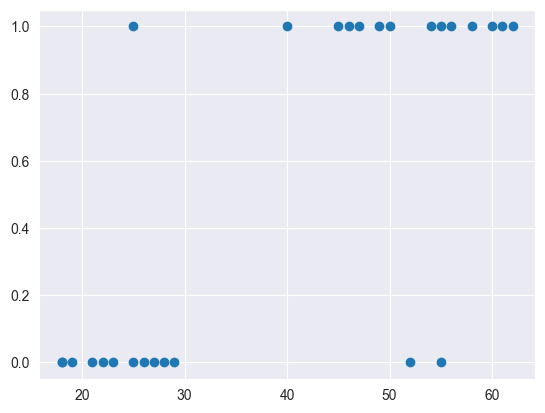

In [3]:
plt.scatter(df.edad, df.compra);

Dividimos el conjunot de datos en 4 variables, 2 por eje, una de entrenamiento y otra de prueba. <br>
El train_size es para poner el % (90%) de datos que pondremos en entrenamiento, el restante (10%) irán a prueba

In [4]:
x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(df[["edad"]], df["compra"], train_size = 0.9)

In [5]:
x_entrena

,edad
9,61
23,45
14,49
25,54
8,62
0,22
17,58
11,28
20,21
10,18


In [6]:
x_prueba

,edad
1,25
12,27
2,47


Creamos el modelo de regresión logistica

In [7]:
modelo = LogisticRegression()

Entrenamos nuestro modelo con los datos de entrenamiento

In [8]:
modelo.fit(x_entrena, y_entrena)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Esto nos da una nota de fiabilidad, este modelo es un 87.5% fiable

In [9]:
modelo.score(x_entrena, y_entrena)

0.875

Creamos nuevos datos para predecir las probabilidades que tendrian de comprar nuestro seguro o no

In [10]:
datos_nuevos = pd.DataFrame({"edad": [25, 63, 28, 37]})
datos_nuevos

,edad
0,25
1,63
2,28
3,37


Y esto predice si nos comprarían (1) o si no (0)

In [11]:
probabilidades =  modelo.predict_proba(datos_nuevos)
probabilidades

array([[0.8431749 , 0.1568251 ],
       [0.04629104, 0.95370896],
       [0.78758044, 0.21241956],
       [0.54871472, 0.45128528]])

In [12]:
prob_si_compra = probabilidades[:,1]
prob_si_compra

array([0.1568251 , 0.95370896, 0.21241956, 0.45128528])

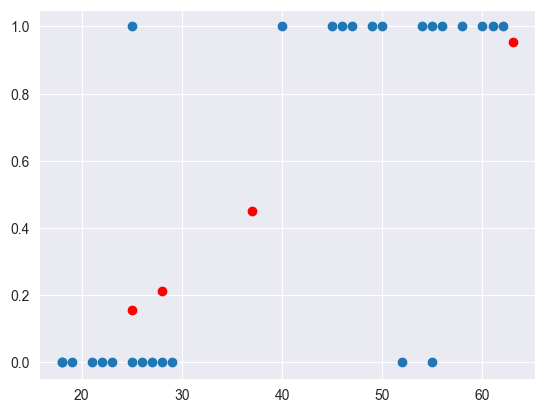

In [13]:
plt.scatter(df.edad, df.compra)
plt.scatter(datos_nuevos["edad"],
            prob_si_compra,
            color = "red");